In [1]:
import numpy as np
import matplotlib.pyplot as plt
from geometry_class import Geometry
from parametrizations import Parameter
from visualization_fct import get_grid, eval_fct_on_grid
from dolfinx.fem import functionspace, Function
import pickle

In [2]:
filename = "./solutions/snow_heterogeneous.pkl"
with open(filename, "rb") as f:
    data_Annika = pickle.load(f)

nx = data_Annika["geometry"]["nx"]
nz = data_Annika["geometry"]["nz"]
geom = Geometry()
geom.make_from_dict(data_Annika["geometry"])
domain = geom.make_domain(nx, nz)
[P0, P1, P2, P3] = geom.corner_points
V = functionspace(domain, ("CG", 1))
hw = Function(V)
phi = Function(V)
layer_params = {
    1: {
        "d_i": 2.31e-4,
        "rho_s": 387,
        "locator": lambda x: x[1] >= geom.slope*x[0] + P3[1]/2 - 1e-14},
    2: {
        "d_i": 4.21e-4,
        "rho_s": 489,
        "locator": lambda x: x[1] < geom.slope*x[0] + P3[1]/2 - 1e-14,}
}
p = Parameter(domain, layer_params)

In [3]:
t_obs = 3
hw.x.array[:] = data_Annika["h_w"][t_obs]
phi.x.array[:] = data_Annika["phi"]
grid, x_plot, z_plot = get_grid(P0, P1, P2, P3, nx, nz)
pressure_head = eval_fct_on_grid(grid, hw, domain).reshape((nz, nx))
porosity = eval_fct_on_grid(grid, phi, domain).reshape((nz, nx))
alpha_eval = eval_fct_on_grid(grid, p.alpha, domain).reshape((nz, nx))
N_eval = eval_fct_on_grid(grid, p.N, domain).reshape((nz, nx))
h_c = pressure_head * (pressure_head < 0)
def Se(h_c, alpha, N):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
theta_tot = p.theta_r.value + (0.9*porosity - p.theta_r.value)*Se(h_c, alpha_eval, N_eval)
h_tot = pressure_head + grid[:,1].reshape((nz, nx))
d_i_eval = eval_fct_on_grid(grid, p.d_i, domain).reshape((nz, nx))

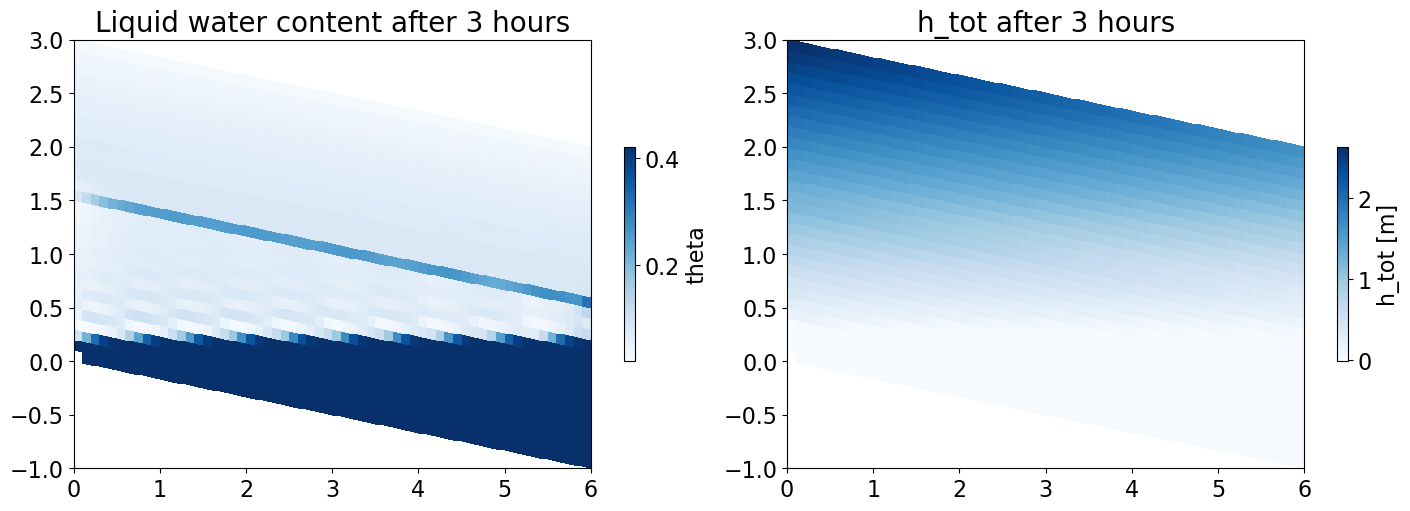

In [8]:
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(1,2, layout="constrained", figsize=(14,5))
pmsh1 = ax[0].pcolormesh(x_plot, z_plot, theta_tot, cmap="Blues")
ax[0].set_title(f"Liquid water content after {t_obs} hours", fontsize=20)
cbar1 = fig.colorbar(pmsh1, ax=ax[0], shrink=0.5)
cbar1.set_label("theta")

pmsh2 = ax[1].pcolormesh(x_plot, z_plot, h_tot, cmap="Blues")
ax[1].set_title(f"h_tot after {t_obs} hours", fontsize=20)
plt.xticks(fontsize=16)
cbar2 = fig.colorbar(pmsh2, ax=ax[1], shrink=0.5)
cbar2.set_label("h_tot [m]")